# Practice Lab – Neural Network 1
## Neural Network Implementation from Scratch

**Name of Student:** Samarth Vijay Chaudhari
**PRN Number:** 202502110004
**Batch:** A3
**Date of Submission:** 19-08-2026

**Class:** T.Y. BTech  
**Course:** Generative AI Lab  
**Department:** CSE AIML

---

### Objective

Implement a simple feedforward neural network from scratch in Python without using any in-built deep learning libraries. The implementation covers forward pass, backpropagation, and training using gradient descent.


# Part A – Problem Definition

### Dataset
The Iris dataset is used for this implementation. It contains four input features:

- Sepal length
- Sepal width
- Petal length
- Petal width

The dataset has three output classes:

- Setosa
- Versicolor
- Virginica

### Task
The task is a multi-class classification problem. The neural network receives the four flower measurements and predicts the correct flower class.


In [1]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# Load the Iris dataset

iris = load_iris()

features = iris.data
labels = iris.target
class_names = iris.target_names

print("Feature shape:", features.shape)
print("Label shape:", labels.shape)
print("Classes:", class_names)


Feature shape: (150, 4)
Label shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [3]:
# Split the dataset into training and testing data

x_train, x_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])


Training samples: 120
Testing samples: 30


In [4]:
# Standardize the input values

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [5]:
# Convert class labels into one-hot encoded form

def make_one_hot(values, total_classes):
    encoded = np.zeros((len(values), total_classes))

    for row_index, class_index in enumerate(values):
        encoded[row_index, class_index] = 1

    return encoded

y_train_hot = make_one_hot(y_train, 3)
y_test_hot = make_one_hot(y_test, 3)

print("One-hot encoded training labels shape:", y_train_hot.shape)


One-hot encoded training labels shape: (120, 3)


# Part B – Neural Network Architecture

The network used in this assignment has:

- **Input layer:** 4 neurons
- **Hidden layer:** 8 neurons
- **Output layer:** 3 neurons

The hidden layer uses the **ReLU activation function**.  
The output layer uses the **Softmax activation function**.

Architecture:

`4 Input Neurons → 8 Hidden Neurons → 3 Output Neurons`


In [6]:
# Set a seed so that the results can be reproduced

np.random.seed(42)

input_count = 4
hidden_count = 8
output_count = 3

# Small random values are used to initialize the weights
w_input_hidden = np.random.randn(input_count, hidden_count) * 0.01
b_hidden = np.zeros((1, hidden_count))

w_hidden_output = np.random.randn(hidden_count, output_count) * 0.01
b_output = np.zeros((1, output_count))


# Part C – Activation Functions

The following activation functions are implemented manually:

1. **ReLU** for the hidden layer
2. **Softmax** for the output layer

The derivative of ReLU is also implemented for backpropagation.


In [7]:
# ReLU activation function

def relu(values):
    return np.maximum(0, values)


# Derivative of ReLU

def relu_gradient(values):
    return (values > 0).astype(float)


# Softmax activation function

def softmax(values):
    shifted_values = values - np.max(values, axis=1, keepdims=True)
    exp_values = np.exp(shifted_values)

    return exp_values / np.sum(exp_values, axis=1, keepdims=True)


# Part D – Forward Pass

During the forward pass:

1. Input values are multiplied by the first set of weights.
2. Bias is added.
3. ReLU is applied to produce hidden layer values.
4. Hidden layer values are passed to the output layer.
5. Softmax converts the output into class probabilities.


In [8]:
# Forward propagation

def forward_pass(input_data):
    hidden_linear = np.dot(input_data, w_input_hidden) + b_hidden
    hidden_output = relu(hidden_linear)

    final_linear = np.dot(hidden_output, w_hidden_output) + b_output
    predicted_values = softmax(final_linear)

    return hidden_linear, hidden_output, final_linear, predicted_values


# Part E – Loss Function

For this classification problem, **Cross-Entropy Loss** is used.

The loss becomes smaller when the predicted probabilities are closer to the correct class.


In [9]:
# Cross-entropy loss

def cross_entropy(actual, predicted):
    safe_prediction = np.clip(predicted, 1e-12, 1 - 1e-12)

    total_loss = -np.sum(actual * np.log(safe_prediction))
    return total_loss / actual.shape[0]


# Part F – Backpropagation

Backpropagation calculates how much each weight contributed to the prediction error.

The gradients are calculated from the output layer back to the hidden layer. These gradients are then used by gradient descent to update the weights and biases.


In [10]:
# Backpropagation

def backward_pass(input_data, actual, hidden_linear, hidden_output, predicted_values):
    sample_count = input_data.shape[0]

    # Output layer gradients
    output_error = (predicted_values - actual) / sample_count

    grad_w_hidden_output = np.dot(hidden_output.T, output_error)
    grad_b_output = np.sum(output_error, axis=0, keepdims=True)

    # Hidden layer gradients
    hidden_error = np.dot(output_error, w_hidden_output.T)
    hidden_error = hidden_error * relu_gradient(hidden_linear)

    grad_w_input_hidden = np.dot(input_data.T, hidden_error)
    grad_b_hidden = np.sum(hidden_error, axis=0, keepdims=True)

    return (
        grad_w_input_hidden,
        grad_b_hidden,
        grad_w_hidden_output,
        grad_b_output
    )


# Part G – Training Using Gradient Descent

The network is trained by repeating the following steps:

1. Perform forward propagation.
2. Calculate the loss.
3. Perform backpropagation.
4. Update weights and biases.
5. Repeat for multiple epochs.


In [11]:
# Training settings

learning_rate = 0.05
epochs = 1500

loss_history = []
training_accuracy = []


In [12]:
# Train the neural network

for epoch in range(epochs):

    # Forward pass
    hidden_linear, hidden_output, final_linear, predicted_values = forward_pass(x_train)

    # Calculate loss
    current_loss = cross_entropy(y_train_hot, predicted_values)

    # Backward pass
    (
        grad_w_input_hidden,
        grad_b_hidden,
        grad_w_hidden_output,
        grad_b_output
    ) = backward_pass(
        x_train,
        y_train_hot,
        hidden_linear,
        hidden_output,
        predicted_values
    )

    # Update weights and biases
    w_input_hidden -= learning_rate * grad_w_input_hidden
    b_hidden -= learning_rate * grad_b_hidden

    w_hidden_output -= learning_rate * grad_w_hidden_output
    b_output -= learning_rate * grad_b_output

    # Store training results
    predicted_classes = np.argmax(predicted_values, axis=1)
    current_accuracy = np.mean(predicted_classes == y_train)

    loss_history.append(current_loss)
    training_accuracy.append(current_accuracy)

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Loss: {current_loss:.4f} | "
            f"Accuracy: {current_accuracy:.4f}"
        )


Epoch 100/1500 | Loss: 1.0875 | Accuracy: 0.6667
Epoch 200/1500 | Loss: 0.6041 | Accuracy: 0.7167
Epoch 300/1500 | Loss: 0.3726 | Accuracy: 0.8750
Epoch 400/1500 | Loss: 0.2768 | Accuracy: 0.9000
Epoch 500/1500 | Loss: 0.2168 | Accuracy: 0.9417
Epoch 600/1500 | Loss: 0.1734 | Accuracy: 0.9583
Epoch 700/1500 | Loss: 0.1416 | Accuracy: 0.9583
Epoch 800/1500 | Loss: 0.1190 | Accuracy: 0.9750
Epoch 900/1500 | Loss: 0.1030 | Accuracy: 0.9750
Epoch 1000/1500 | Loss: 0.0917 | Accuracy: 0.9750
Epoch 1100/1500 | Loss: 0.0834 | Accuracy: 0.9750
Epoch 1200/1500 | Loss: 0.0771 | Accuracy: 0.9750
Epoch 1300/1500 | Loss: 0.0722 | Accuracy: 0.9750
Epoch 1400/1500 | Loss: 0.0683 | Accuracy: 0.9750
Epoch 1500/1500 | Loss: 0.0651 | Accuracy: 0.9750


# Part H – Model Evaluation

After training, the model is tested using data that was not used for updating the weights.

The final evaluation includes:

- Test accuracy
- Classification report
- Confusion matrix


In [13]:
# Make predictions on the test data

_, _, _, test_probabilities = forward_pass(x_test)

test_predictions = np.argmax(test_probabilities, axis=1)

test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, test_predictions, target_names=class_names))


Test Accuracy: 0.9667

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



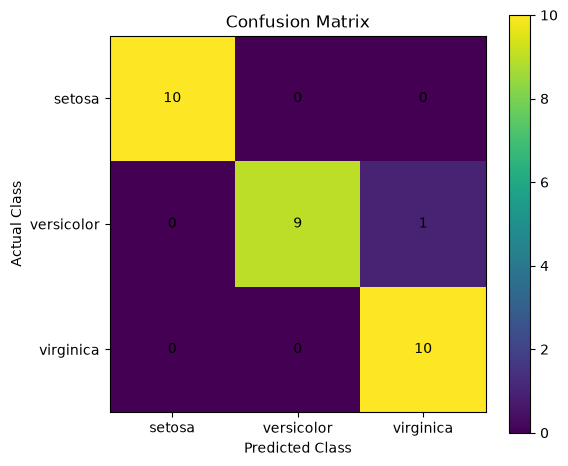

In [14]:
# Display the confusion matrix

matrix = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(3), class_names)
plt.yticks(range(3), class_names)

for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        plt.text(column, row, matrix[row, column], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


# Part I – Training Visualizations

The following graphs show how the neural network changes during training:

- Loss over epochs
- Training accuracy over epochs


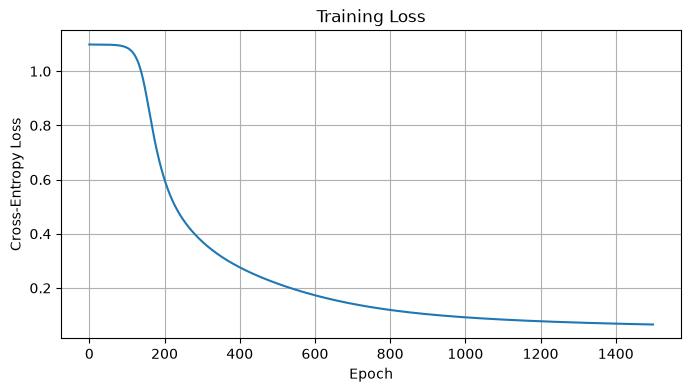

In [15]:
# Plot training loss

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid()
plt.show()


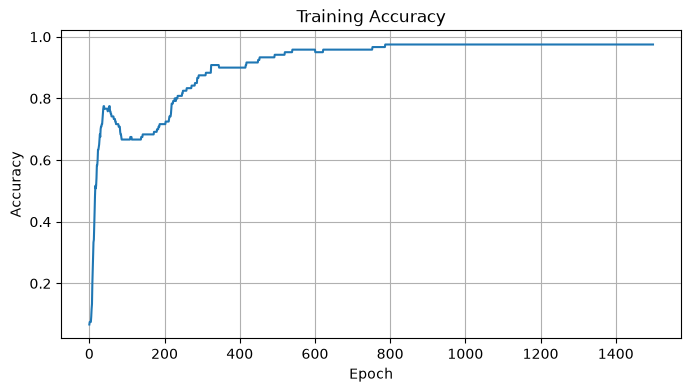

In [16]:
# Plot training accuracy

plt.figure(figsize=(8, 4))
plt.plot(training_accuracy)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


# Part J – Results and Conclusion


### Conclusion

This experiment demonstrates the basic working of a feedforward neural network. By manually implementing forward propagation and backpropagation, it becomes easier to understand how a neural network learns by calculating errors and gradually updating its weights.


# Declaration & Submission Checklist

### Declaration
I, **Samarth Vijay Chaudhari**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

**GitHub Repository Link:** 

**Signature:** Samarth Vijay Chaudhari
